# Machine Learning Lab - Experiment 3

## Decision Tree Classifier - HousePurchase

### Aim

To Predict whether a user purchases a product based on age and estimated salary.

In [4]:
# ------------------------------------------------------------
# 1. Import required libraries
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
# ------------------------------------------------------------
# 2. Upload the CSV file
# ------------------------------------------------------------
uploaded = files.upload()

Saving Social_Network_Ads.csv to Social_Network_Ads.csv


In [6]:
# ------------------------------------------------------------
# 3. Read the CSV file
# ------------------------------------------------------------

df = pd.read_csv("Social_Network_Ads.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0

Dataset shape:
(400, 5)

Missing values:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [7]:
# ------------------------------------------------------------
# 4. Select required variables
# ------------------------------------------------------------

# Age -> first variable
# EstimatedSalary -> Income
# Purchased -> Target

df = df[["Age", "EstimatedSalary", "Purchased"]]

# Rename columns according to the question
df.columns = ["Age", "Income", "BuyHouse"]

print("\nSelected data:")
print(df.head())


Selected data:
   Age  Income  BuyHouse
0   19   19000         0
1   35   20000         0
2   26   43000         0
3   27   57000         0
4   19   76000         0


In [8]:
# ------------------------------------------------------------
# 5. Check the Age > 30 split described in the question
# ------------------------------------------------------------

over_30 = df[df["Age"] > 30]

total_over_30 = len(over_30)
bought_over_30 = (over_30["BuyHouse"] == 1).sum()
not_bought_over_30 = (over_30["BuyHouse"] == 0).sum()

print("\n----- Age > 30 Split -----")

print("Number of people over age 30:", total_over_30)
print("Bought a house:", bought_over_30)
print("Did not buy:", not_bought_over_30)

if total_over_30 > 0:
    purchase_percentage = bought_over_30 / total_over_30 * 100
    print("Percentage who bought:", round(purchase_percentage, 2), "%")


----- Age > 30 Split -----
Number of people over age 30: 289
Bought a house: 137
Did not buy: 152
Percentage who bought: 47.4 %


In [9]:
# ------------------------------------------------------------
# 6. Calculate purity for Age > 30
# ------------------------------------------------------------

if total_over_30 > 0:

    majority_class = max(
        bought_over_30,
        not_bought_over_30
    )

    purity = majority_class / total_over_30 * 100

    print("Purity of Age > 30 group:", round(purity, 2), "%")

Purity of Age > 30 group: 52.6 %


In [10]:
# ------------------------------------------------------------
# 7. Prepare features and target
# ------------------------------------------------------------

X = df[["Age", "Income"]]
y = df["BuyHouse"]

In [11]:
# ------------------------------------------------------------
# 8. Split data into training and testing data
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [12]:
# ------------------------------------------------------------
# 9. Create Decision Tree Classifier
# ------------------------------------------------------------

model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

In [13]:
# ------------------------------------------------------------
# 10. Train the model
# ------------------------------------------------------------

model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [14]:
# ------------------------------------------------------------
# 11. Make predictions
# ------------------------------------------------------------

y_pred = model.predict(X_test)

In [15]:
# ------------------------------------------------------------
# 12. Calculate accuracy
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n----- Model Performance -----")
print("Accuracy:", round(accuracy * 100, 2), "%")


----- Model Performance -----
Accuracy: 88.75 %


In [16]:
# ------------------------------------------------------------
# 13. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[45  6]
 [ 3 26]]


In [17]:
# ------------------------------------------------------------
# 14. Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Purchase", "Purchase"]
    )
)


Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.94      0.88      0.91        51
    Purchase       0.81      0.90      0.85        29

    accuracy                           0.89        80
   macro avg       0.88      0.89      0.88        80
weighted avg       0.89      0.89      0.89        80



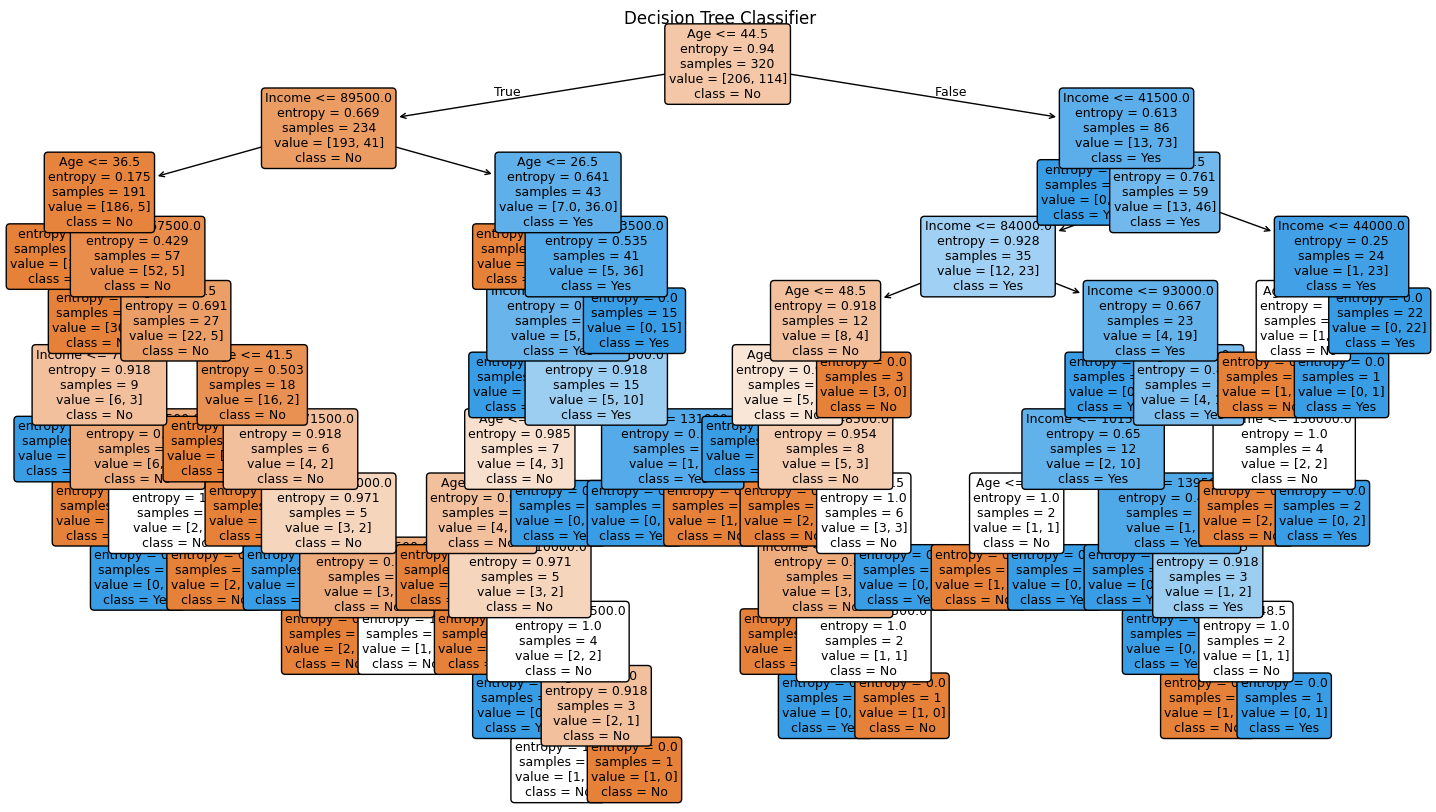

In [18]:
# ------------------------------------------------------------
# 15. Display the Decision Tree
# ------------------------------------------------------------

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=["Age", "Income"],
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree Classifier")
plt.show()

In [19]:
# ------------------------------------------------------------
# 16. Predict for a new customer
# ------------------------------------------------------------

new_customer = pd.DataFrame({
    "Age": [35],
    "Income": [60000]
})

prediction = model.predict(new_customer)[0]

print("\n----- New Customer Prediction -----")

print("Age:", new_customer["Age"].iloc[0])
print("Income:", new_customer["Income"].iloc[0])

if prediction == 1:
    print("Prediction: Buys the product")
else:
    print("Prediction: Does not buy the product")


----- New Customer Prediction -----
Age: 35
Income: 60000
Prediction: Does not buy the product
